In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import tensorflow as tf

In [2]:
df = pd.read_csv("../data/Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [4]:
print(df.shape)

(10000, 14)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

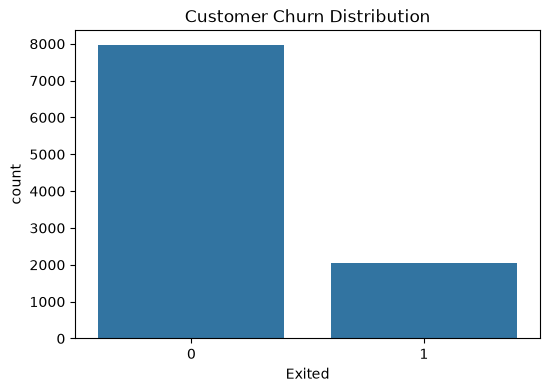

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="Exited",
    data=df
)
plt.title("Customer Churn Distribution")

plt.savefig("../images/exited.png")
plt.show()

In [11]:
df.drop(
    columns=[
        "RowNumber",
        "CustomerId",
        "Surname"
    ],
    inplace=True
)

In [12]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
print(df.dtypes)

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [14]:
label_encoder = LabelEncoder()

df["Gender"] = label_encoder.fit_transform(df["Gender"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [15]:
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)
bool_columns = df.select_dtypes(include="bool").columns 
df[bool_columns] = df[bool_columns].astype(int)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [16]:
X = df.drop("Exited", axis = 1)
y = df["Exited"]

print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 11)
(2000, 11)
(8000,)
(2000,)


In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train[:5])

[[ 0.35649971  0.91324755 -0.6557859   0.34567966 -1.21847056  0.80843615
   0.64920267  0.97481699  1.36766974 -0.57946723 -0.57638802]
 [-0.20389777  0.91324755  0.29493847 -0.3483691   0.69683765  0.80843615
   0.64920267  0.97481699  1.6612541   1.72572313 -0.57638802]
 [-0.96147213  0.91324755 -1.41636539 -0.69539349  0.61862909 -0.91668767
   0.64920267 -1.02583358 -0.25280688 -0.57946723  1.73494238]
 [-0.94071667 -1.09499335 -1.13114808  1.38675281  0.95321202 -0.91668767
   0.64920267 -1.02583358  0.91539272 -0.57946723 -0.57638802]
 [-1.39733684  0.91324755  1.62595257  1.38675281  1.05744869 -0.91668767
  -1.54035103 -1.02583358 -1.05960019 -0.57946723 -0.57638802]]


In [21]:
model = tf.keras.Sequential([
    tf.keras.Input(shape = (11, )),
    tf.keras.layers.Dense(16, activation = "relu"),
    tf.keras.layers.Dense(8, activation = "relu"),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

history = model.fit(X_train, y_train, epochs = 20, batch_size = 32, validation_split = 0.2)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7934 - loss: 0.5531 - val_accuracy: 0.7987 - val_loss: 0.4854
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - accuracy: 0.7944 - loss: 0.4671 - val_accuracy: 0.8019 - val_loss: 0.4300
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - accuracy: 0.8069 - loss: 0.4314 - val_accuracy: 0.8250 - val_loss: 0.4083
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 600us/step - accuracy: 0.8264 - loss: 0.4123 - val_accuracy: 0.8394 - val_loss: 0.3976
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - accuracy: 0.8344 - loss: 0.3967 - val_accuracy: 0.8431 - val_loss: 0.3871
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - accuracy: 0.8413 - loss: 0.3810 - val_accuracy: 0.8494 - val_loss: 0.3752
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - accuracy: 0.8486 - loss: 0.3683 - val_accuracy: 0.8519 - val_loss: 0.3670
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step - accuracy: 0.8525 - loss: 0.3592 - va

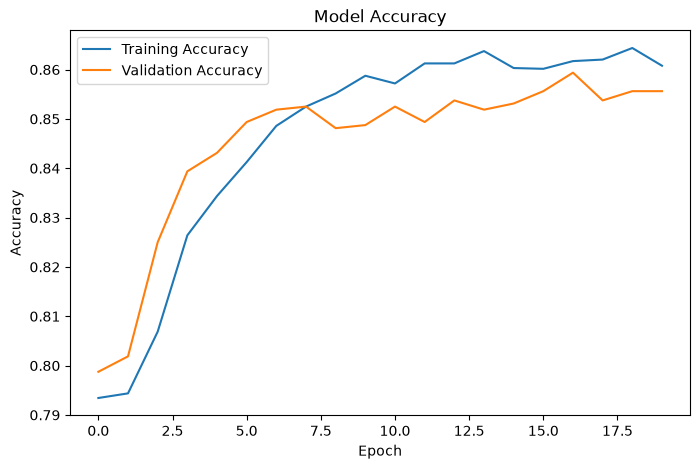

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("../images/epoch_vs_accuracy.png")
plt.show()

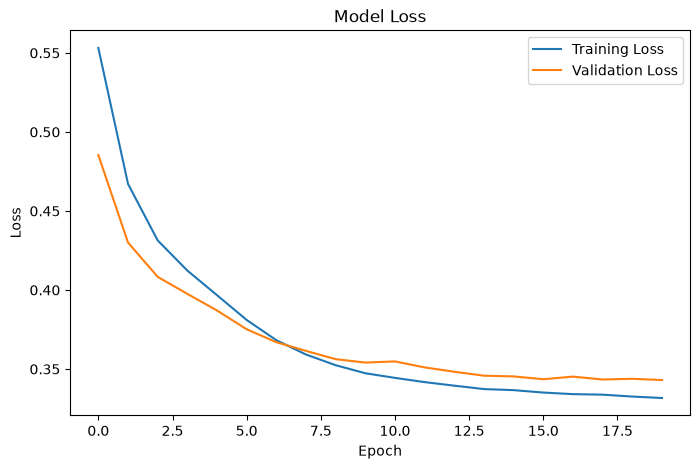

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../images/epoch_vs_loss.png")
plt.show()

In [25]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - accuracy: 0.8610 - loss: 0.3420 
Test Loss : 0.3419535160064697
Test Accuracy : 0.8610000014305115


In [27]:
predictions = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step


In [29]:
print(predictions[:10])

[[0.03560486]
 [0.02860609]
 [0.08875128]
 [0.15086453]
 [0.06154034]
 [0.01053159]
 [0.11628798]
 [0.16091317]
 [0.29919285]
 [0.52075267]]


In [31]:
predictions = (predictions > 0.5).astype(int)
print(predictions[:10])

[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]]


In [32]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions.flatten()
})
comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,0
8,0,0
9,0,1


In [34]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[1540   67]
 [ 211  182]]


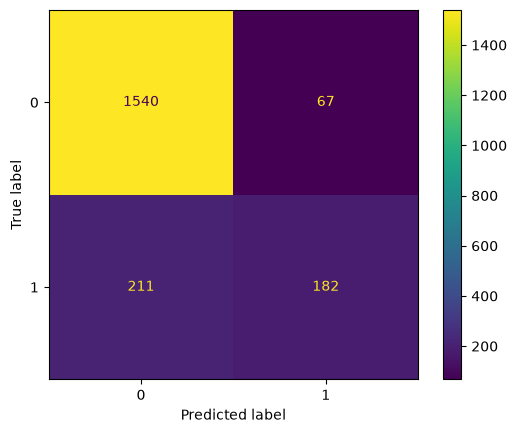

In [35]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.savefig("../images/confusion_matrix.png")
plt.show()

In [36]:
print(
    classification_report(y_test, predictions)
)

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.73      0.46      0.57       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [38]:
model.save("../models/churn_model.keras")

In [39]:
loaded_model = tf.keras.models.load_model("../models/churn_model.keras")

In [40]:
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013 (3.96 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 676 (2.64 KB)

In [41]:
loaded_prediction = loaded_model.predict(X_test[:5])
print(loaded_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
[[0.03560486]
 [0.02860609]
 [0.08875126]
 [0.15086453]
 [0.06154034]]
